# PPLMs
This script conducts PPML and penalized PPML estimates.

#### Libraries

In [ ]:
import pandas as pd
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Connect to Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'
export_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'

Data uploading

In [ ]:
merged_main = pd.read_csv(import_path + "merged_main_final.csv",
                          dtype={"exp_iso3": str, "imp_iso3": str})
merged_robust = pd.read_csv(import_path + "merged_robust_final.csv",
                            dtype={"exp_iso3": str, "imp_iso3": str})
print(merged_main.shape, merged_robust.shape)

/tmp/ipykernel_1207/1870831702.py:3: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_robust = pd.read_csv(import_path + "merged_robust_final.csv",


(1404170, 54) (1404170, 54)


## Columns tidy

In [ ]:
print(merged_main.columns.tolist())

['year', 'exp_iso3', 'imp_iso3', 'exp_id', 'imp_id', 'trade', 'trade_comtrade', 'dist', 'dist_cap', 'dist_w_harm', 'dist_w_arith', 'dist_w_harm_jh', 'dist_w_arith_jh', 'contig', 'comlang', 'comcol', 'colony', 'exp_gdp', 'imp_gdp', 'exp_gdppc', 'imp_gdppc', 'exp_pop', 'imp_pop', 'fta', 'exp_eu', 'imp_eu', 'exp_wto', 'imp_wto', 'case_id', 'sanc_arms', 'sanc_military', 'sanc_trade', 'sanc_financial', 'sanc_travel', 'sanc_other', 'target_mult', 'sender_mult', 'sanctioned_any', 'descr_exp_compl', 'descr_exp_part', 'descr_imp_compl', 'descr_imp_part', 'obj_democracy', 'obj_destab_regime', 'obj_end_war', 'obj_human_rights', 'obj_other', 'obj_policy_change', 'obj_prevent_war', 'obj_territorial_conflict', 'obj_terrorism', 'rta_Goods', 'rta_Goods & Services', 'rta_Services']


### Column reference (54 columns)

**Keys / identifiers (5)** — used for fixed effects and merging, not features:
`year`, `exp_iso3`, `imp_iso3`, `exp_id`, `imp_id`

**Outcome (2):**
- `trade` — PPML dependent variable (main outcome).
- `trade_comtrade` — alternative longer-coverage outcome, kept for a robustness run, not used in the main model.

**Droppable identifier (1):**
- `case_id` — GSDB case identifier, not a model input (source of the mixed-type DtypeWarning). Dropped before modeling.

**Gravity controls (21)** — largely absorbed by fixed effects in the core PPML, retained for the tree and DML stages:
`dist`, `dist_cap`, `dist_w_harm`, `dist_w_arith`, `dist_w_harm_jh`, `dist_w_arith_jh`, `contig`, `comlang`, `comcol`, `colony`, `exp_gdp`, `imp_gdp`, `exp_gdppc`, `imp_gdppc`, `exp_pop`, `imp_pop`, `fta`, `exp_eu`, `imp_eu`, `exp_wto`, `imp_wto`

**Sanction features (25)** — the variables of interest, over which LASSO selects:
- *Type flags (6):* `sanc_arms`, `sanc_military`, `sanc_trade`, `sanc_financial`, `sanc_travel`, `sanc_other`
- *Multilateral (2):* `target_mult`, `sender_mult`
- *Direction / intensity (4):* `descr_exp_compl`, `descr_exp_part`, `descr_imp_compl`, `descr_imp_part`
- *Objective (9):* `obj_democracy`, `obj_destab_regime`, `obj_end_war`, `obj_human_rights`, `obj_other`, `obj_policy_change`, `obj_prevent_war`, `obj_territorial_conflict`, `obj_terrorism`
- *Aggregate indicator (1):* `sanctioned_any` — useful as the DML treatment and for diagnostics; excluded from the LASSO, as it is collinear with the individual type flags.

**RTA control (3):** `rta_Goods`, `rta_Goods & Services`, `rta_Services`

In [ ]:
# Drop useless identifier
for df_ in (merged_main, merged_robust):
    df_.drop(columns=["case_id"], inplace=True, errors="ignore")

In [ ]:
# Keep population-weighted harmonic distance (CEPII/gravity-literature standard); drop redundant variants
drop_dist = ["dist", "dist_cap", "dist_w_arith", "dist_w_harm_jh", "dist_w_arith_jh"]
for df_ in (merged_main, merged_robust):
    df_.drop(columns=drop_dist, inplace=True, errors="ignore")

print(len(merged_main.columns), "columns")
print([c for c in merged_main.columns if "dist" in c])   # should show only dist_w_harm

48 columns
['dist_w_harm']


## Data preparation



### Feature set definition

In [ ]:
# Build slim R inputs
ids, dep = ["exp_iso3", "imp_iso3", "year"], "trade"

sanc_feats = [
    "sanc_arms","sanc_military","sanc_trade","sanc_financial","sanc_travel","sanc_other",
    "target_mult","sender_mult",
    "descr_exp_compl","descr_exp_part","descr_imp_compl","descr_imp_part",
    "obj_democracy","obj_destab_regime","obj_end_war","obj_human_rights","obj_other",
    "obj_policy_change","obj_prevent_war","obj_territorial_conflict","obj_terrorism",
]   # sanctioned_any EXCLUDED — aggregate treatment, collinear with type flags

need = ids + [dep] + sanc_feats + ["sanctioned_any"]
assert all(c in merged_main.columns for c in need), [c for c in need if c not in merged_main.columns]
print(len(sanc_feats), "penalized features")   # verify against panel

21 penalized features


In [ ]:
merged_main[[dep]+ids+["sanctioned_any"]].to_csv(export_path + "bench_input.csv", index=False)
merged_main[[dep]+ids+sanc_feats].to_csv(export_path + "lasso_input.csv", index=False)

### R setup

R environment (penppml via binaries)


Colab's R can't compile fixest/dreamerr from source. rspm serves Posit binaries
instead. Run the two setup cells once after each runtime restart, then the fread
cell, then modeling. If binaries ever fail, fallback: `!apt-get install -y r-cran-penppml`

In [ ]:
# ── R environment setup (run once per fresh Colab runtime) ──
# penppml needs fixest/dreamerr; these fail to compile from source on Colab's R,
# so we install prebuilt binaries via rspm. apt-file is required by rspm::enable().
!apt-get -qq install -y apt-file && apt-file update

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,588 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,959 kB]
Fetched 12.7 MB in 2s (7,128 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
15 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping a

In [ ]:
%%R
# One-time install. rspm::enable() switches CRAN to Posit binaries (no compilation)
# and resolves system libraries. Safe to re-run — installed packages are skipped.
if (!requireNamespace("rspm", quietly=TRUE)) install.packages("rspm")
rspm::enable()
for (p in c("penppml","fixest","dreamerr","data.table","reshape2","ggplot2","ggrepel"))
  if (!requireNamespace(p, quietly=TRUE)) install.packages(p)

library(penppml); library(data.table)

Tracing function "install.packages" in package "utils"
Tracing function "update.packages" in package "utils"


In [ ]:
%%R
"penppml" %in% (.packages())   # TRUE = loaded and ready

[1] TRUE


#### Function for a nice regression table output.

In [ ]:
%%R
if (!requireNamespace("gt",       quietly=TRUE)) install.packages("gt")
if (!requireNamespace("xtable",   quietly=TRUE)) install.packages("xtable")
library(gt); library(xtable)

# ── shared core: derive the reporting columns from term/b/se ──
ppml_prep <- function(df) {
  df$pct   <- 100 * (exp(df$b) - 1)          # PPML semi-elasticity → % effect
  df$t     <- df$b / df$se
  df$p     <- 2 * pnorm(-abs(df$t))          # large-sample z-test, clustered SE
  df$stars <- as.character(cut(df$p, c(-Inf,.01,.05,.1,Inf),
                               labels = c("***","**","*","")))
  df
}

NOTE <- "PPML, three-way FE (exp×year, imp×year, pair); SE clustered by pair. *** p<.01, ** p<.05, * p<.1"

# ── 1) VIEW in Colab ──
ppml_gt <- function(df, title, subtitle = NULL) {
  d <- ppml_prep(df)
  gt(d) |>
    tab_header(title = title, subtitle = subtitle) |>
    cols_label(term="Dimension", b="β", se="SE", pct="% effect",
               t="t", p="p", stars="") |>
    fmt_number(c(b, se, t), decimals = 4) |>
    fmt_number(pct, decimals = 1) |>
    fmt_number(p,   decimals = 3) |>
    cols_align("left", term) |>
    tab_source_note(NOTE)
}

# ── 2) EXPORT to LaTeX ──
# ── LaTeX table → printed to output only (no file) ──
ppml_latex <- function(df, title, label) {
  d <- ppml_prep(df)
  d$b_fmt   <- sprintf("%.4f%s", d$b, d$stars)   # coefficient with stars
  d$se_fmt  <- sprintf("(%.4f)", d$se)           # SE in parentheses
  d$pct_fmt <- sprintf("%.1f", d$pct)
  out <- d[, c("term","b_fmt","se_fmt","pct_fmt")]
  names(out) <- c("Dimension", "$\\beta$", "SE", "\\% effect")

  xt <- xtable(out, caption = title, label = label, align = "llccc")
  print(xt, include.rownames = FALSE, booktabs = TRUE,
        sanitize.text.function = identity,
        caption.placement = "top",
        add.to.row = list(pos = list(nrow(out)),
                          command = sprintf("\\midrule \\multicolumn{4}{l}{\\footnotesize %s}\\\\", NOTE)))
}

### Data uploading

In [ ]:
%%R
path  <- "/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/"
lasso <- as.data.frame(fread(paste0(path, "lasso_input.csv")))
bench <- as.data.frame(fread(paste0(path, "bench_input.csv")))
for (c in c("exp_iso3","imp_iso3","year")) {
  lasso[[c]] <- as.character(lasso[[c]]); bench[[c]] <- as.character(bench[[c]])
}
str(lasso)   # expect: 25 cols (trade + 3 ids + 21 features), ~1.4M rows

'data.frame':	1404170 obs. of  25 variables:
 $ trade                   : num  0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 ...
 $ exp_iso3                : chr  "TTO" "WSM" "ALB" "AGO" ...
 $ imp_iso3                : chr  "RWA" "SVN" "EGY" "NER" ...
 $ year                    : chr  "2013" "2005" "2004" "2005" ...
 $ sanc_arms               : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sanc_military           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sanc_trade              : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sanc_financial          : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sanc_travel             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sanc_other              : num  0 0 0 0 0 0 0 0 0 0 ...
 $ target_mult             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ sender_mult             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ descr_exp_compl         : int  0 0 0 0 0 0 0 0 0 0 ...
 $ descr_exp_part          : int  0 0 0 0 0 0 0 0 0 0 ...
 $ descr_imp_compl         : int  0 0 0 0 0 0 0 0 0 0 ...
 $ descr_imp_part          : 

Trade has suspeciously sae values- let's investigate.

In [ ]:
%%R
summary(lasso$trade)
c(exact_zero = mean(lasso$trade == 0),      # share sitting at exactly 0
  at_0.001   = mean(lasso$trade == 0.001))  # share floored to 0.001

  exact_zero     at_0.001 
0.5094532713 0.0001616613 


Seems like these are just, indeed, very small values of trade, not 'hidden zeros'.

Check the number of zeros (generated and not) for Lasso dataset. It's huge- sanctions are rare events.

In [ ]:
%%R
feats <- setdiff(names(lasso), c("trade","exp_iso3","imp_iso3","year"))
data.frame(
  feature = feats,
  ones    = sapply(lasso[feats], sum),
  share   = round(sapply(lasso[feats], mean), 5)
)[order(-sapply(lasso[feats], sum)), ]

                                          feature  ones   share
sender_mult                           sender_mult 85376 0.06080
sanc_arms                               sanc_arms 70830 0.05044
sanc_financial                     sanc_financial 52156 0.03714
obj_end_war                           obj_end_war 50689 0.03610
sanc_travel                           sanc_travel 49640 0.03535
sanc_military                       sanc_military 47106 0.03355
obj_human_rights                 obj_human_rights 29102 0.02073
sanc_trade                             sanc_trade 26859 0.01913
obj_prevent_war                   obj_prevent_war 23861 0.01699
sanc_other                             sanc_other 20612 0.01468
descr_exp_part                     descr_exp_part 16450 0.01172
descr_imp_part                     descr_imp_part 15667 0.01116
obj_democracy                       obj_democracy 13387 0.00953
obj_terrorism                       obj_terrorism 12814 0.00913
target_mult                           ta

## PPLM
**Poisson Pseudo-Maximum Likelihood (PPML)**

PPML models the **conditional mean of trade** as an exponential function of observed covariates and fixed effects:

$$
\mu_{ijt}
=
E(y_{ijt} \mid x_{ijt}, \alpha_{it}, \gamma_{jt}, \eta_{ij})
=
\exp(x_{ijt}'\beta + \alpha_{it} + \gamma_{jt} + \eta_{ij})
$$

Here, $\mu_{ijt}$ is the **conditional expected (predicted) trade flow** from exporter $i$ to importer $j$ in year $t$, given the explanatory variables and fixed effects. Because $\mu_{ijt}$ is specified using the exponential function, it is always positive.

The variable $y_{ijt}$ is the observed trade flow from exporter $i$ to importer $j$ in year $t$, $x_{ijt}$ contains the explanatory variables, and $\alpha_{it}$, $\gamma_{jt}$, and $\eta_{ij}$ denote exporter-year, importer-year, and country-pair fixed effects.

The **standard non-penalized PPML estimator** minimizes the negative Poisson pseudo-log-likelihood:

$$
L(\beta,\alpha,\gamma,\eta)
=
\frac{1}{n}
\sum_{i,j,t}
\left(
\mu_{ijt} - y_{ijt}\ln(\mu_{ijt})
\right)
$$

PPML is particularly useful for trade data because it naturally accommodates **zero trade flows** and does not require taking $\log(y_{ijt})$.

In [ ]:
%%R
# benchmark: unpenalized PPML, three-way FE, pair-clustered
bench_reg <- hdfeppml(data    = bench,
                      dep     = "trade",
                      fixed   = list(c("exp_iso3","year"),
                                     c("imp_iso3","year"),
                                     c("exp_iso3","imp_iso3")),
                      cluster = c("exp_iso3","imp_iso3"))

bench_reg$coefficients      # the aggregate sanction effect
str(bench_reg, max.level = 1)   # shows where the SE lives

User did not specify independent variables. By default, the function takes all variables
        not included in 'dep' or 'fixed' as regressors.List of 8
 $ coefficients: num [1, 1] -0.0975
 $ residuals   : num [1:1404170, 1] -0.999 -0.999 -1 -1 -1 ...
 $ mu          : num [1:1404170] 1.756 0.704 669.237 18.439 138.317 ...
 $ deviance    : num 12958
 $ bic         : num 13617
 $ x_resid     : num [1:1404170] -0.1568 -0.0136 -0.3744 -0.0638 0.0974 ...
 $ z_resid     : num [1:1404170, 1] -0.984 -0.997 -0.964 -0.994 -1.009 ...
 $ se          : num 0.0187


View a nicer table

In [ ]:
%%R
tab2 <- data.frame(term = "Any sanction",
                   b    = bench_reg$coefficients[1,1],
                   se   = bench_reg$se[1])

ppml_gt(tab2, "Table 2: Benchmark aggregate sanction effect",
        "Average effect of any sanction on bilateral trade")

In [ ]:
%%R
d <- ppml_prep(tab2)
print(knitr::kable(
  d[, c("term","b","se","pct","t","p","stars")],
  digits = 4, format = "simple",
  col.names = c("Dimension","β","SE","% effect","t","p","")
))



Dimension             β       SE   % effect         t    p      
-------------  --------  -------  ---------  --------  ---  ----
Any sanction    -0.0975   0.0187    -9.2878   -5.2108    0  *** 


Export a nicer table

In [ ]:
%%R
ppml_latex(tab2, "Benchmark aggregate sanction effect on bilateral trade", "tab:benchmark")       # export

% latex table generated in R 4.6.1 by xtable 1.8-4 package
% Mon Aug 24 11:22:10 2026
\begin{table}[ht]
\centering
\caption{Benchmark aggregate sanction effect on bilateral trade} 
\label{tab:benchmark}
\begin{tabular}{lccc}
  \toprule
Dimension & $\beta$ & SE & \% effect \\ 
  \midrule
Any sanction & -0.0975*** & (0.0187) & -9.3 \\ 
   \midrule \multicolumn{4}{l}{\footnotesize PPML, three-way FE (exp×year, imp×year, pair); SE clustered by pair. *** p<.01, ** p<.05, * p<.1}\\ \bottomrule
\end{tabular}
\end{table}


## Penalized PPML

**Poisson Pseudo-Maximum Likelihood with Plug-in Lasso Penalty (PPML-Lasso) - 2 step procedure (like post-Lasso, but with PPML instead of OLS.)**

PPML models the **conditional mean of trade** as an exponential function of observed covariates and fixed effects:

$$\mu_{ijt} = E(y_{ijt} \mid x_{ijt}, \alpha_{it}, \gamma_{jt}, \eta_{ij}) = \exp(x_{ijt}'\beta + \alpha_{it} + \gamma_{jt} + \eta_{ij})$$

Here, $\mu_{ijt}$ is the **conditional expected (predicted) trade flow** from exporter $i$ to importer $j$ in year $t$, given the explanatory variables and fixed effects.

The variable $y_{ijt}$ is the observed trade flow, $x_{ijt}$ contains the explanatory variables, and $\alpha_{it}$, $\gamma_{jt}$, and $\eta_{ij}$ denote exporter-year, importer-year, and country-pair fixed effects.

The **penalized PPML estimator** adds an L1 (Lasso) penalty to the standard PPML objective:

$$PL(\beta,\alpha,\gamma,\eta) = \frac{1}{n}\sum_{i,j,t}\left(\mu_{ijt} - y_{ijt}\ln(\mu_{ijt})\right) + \frac{\lambda}{n}\sum_{k=1}^{p}\hat{\phi}_k|\beta_k|$$

We use the **plug-in Lasso** approach rather than selecting $\lambda$ from a predefined grid or by cross-validation. The overall penalty level is determined theoretically as:

$$\lambda = 1.1\sqrt{n}\Phi^{-1}\left(1-\frac{\gamma}{2p}\right)$$

with:

$$\gamma = \frac{0.1}{\log(n)}$$

where $n$ is the number of observations, $p$ is the number of regressors, and $\Phi^{-1}$ denotes the inverse cumulative distribution function of the standard normal distribution.

The terms $\hat{\phi}_k$ are **regressor-specific penalty loadings** that are estimated from the data and account for heteroskedasticity and the chosen clustering structure. In our specification, the scores are clustered at the **exporter-importer dyad level**.

Thus, the plug-in procedure automatically determines the effective penalty for each coefficient rather than searching over a grid of $\lambda$ values. The penalty is chosen conservatively so that a regressor must have a sufficiently large score relative to its variability to be selected.

The Lasso penalty shrinks the coefficients $\beta_k$ toward zero and can set some coefficients exactly equal to zero. Therefore, plug-in PPML-Lasso performs **variable selection** while still accommodating **zero trade flows** without taking $\log(y_{ijt})$.




### Path plot
coefficients changes by lambda.

In [ ]:
%%R
# sweep lambda from heavy penalty (nothing selected) down to 0 (full PPML)
lambdas <- c(0.05,0.025,0.01,0.0075,0.005,0.0025,0.001,0.00075,0.0005,0.00025,0.0001,0)
reg <- mlfitppml(data    = lasso, dep = "trade",
                 fixed   = list(c("exp_iso3","year"),
                                c("imp_iso3","year"),
                                c("exp_iso3","imp_iso3")),
                 penalty = "lasso", lambdas = lambdas)

# reshape post-penalty coefficients to long format for plotting
results <- as.data.frame(reg$beta); names(results) <- lambdas
results$dimension <- rownames(results)
results <- reshape2::melt(results, id.vars="dimension",
                          variable.name="lambda", value.name="coefficient")
results$lambda <- as.numeric(as.character(results$lambda))
head(results)

User did not specify independent variables. By default, the function takes all variables
        not included in 'dep' or 'fixed' as regressors.[1] 0.05
[1] 0.025
[1] 0.01
[1] 0.0075
[1] 0.005
[1] 0.0025
[1] 0.001
[1] 0.00075
[1] 5e-04
[1] 0.00025
[1] 1e-04
[1] 0
       dimension lambda coefficient
1      sanc_arms   0.05           0
2  sanc_military   0.05           0
3     sanc_trade   0.05           0
4 sanc_financial   0.05           0
5    sanc_travel   0.05           0
6     sanc_other   0.05           0


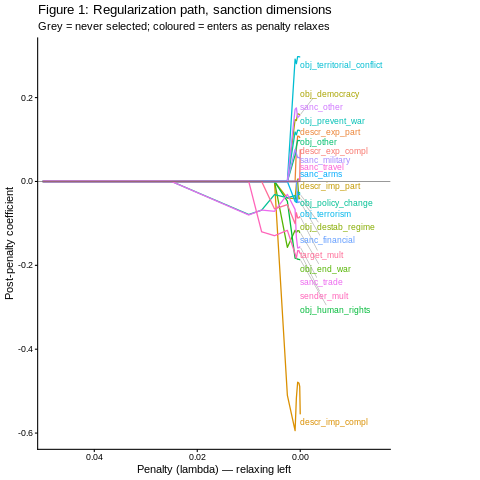

In [ ]:
%%R
library(ggplot2); library(ggrepel); library(dplyr)

fig_path <- sub("Cleaned/?$", "Figures/", path)
dir.create(fig_path, showWarnings = FALSE, recursive = TRUE)

# which dimensions ever leave zero? (label only these)
active <- results |>
  group_by(dimension) |>
  summarise(maxabs = max(abs(coefficient))) |>
  filter(maxabs > 1e-4) |>
  pull(dimension)

results$active <- results$dimension %in% active
labs <- results[results$lambda == min(results$lambda) & results$active, ]

p <- ggplot(results, aes(lambda, coefficient, group = dimension)) +
  # inactive dims: faint grey, no label
  geom_line(data = subset(results, !active), colour = "grey85", linewidth = 0.3) +
  # active dims: coloured
  geom_line(data = subset(results, active), aes(colour = dimension),
            linewidth = 0.6, show.legend = FALSE) +
  geom_hline(yintercept = 0, linewidth = 0.3, colour = "grey40") +
  geom_text_repel(data = labs, aes(label = dimension, colour = dimension),
                  direction = "y", hjust = 0, xlim = c(-0.004, NA),
                  segment.size = 0.3, segment.color = "grey70",
                  size = 3, max.overlaps = Inf, show.legend = FALSE) +
  scale_x_reverse(expand = expansion(mult = c(0.02, 0.35))) +   # room on the right
  theme_classic() +
  theme(plot.margin = margin(5, 90, 5, 5)) +
  labs(x = "Penalty (lambda) — relaxing left", y = "Post-penalty coefficient",
       title = "Figure 1: Regularization path, sanction dimensions",
       subtitle = "Grey = never selected; coloured = enters as penalty relaxes")

# ggsave(paste0(fig_path, "fig1_lasso_path.pdf"), p, width = 10, height = 6)
p

Better plot

In addition: Warning messages:
1: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
2: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
3: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
4: In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Penalty (lambda) — relaxing left' in 'mbcsToSbcs': - substituted for — (U+2014)


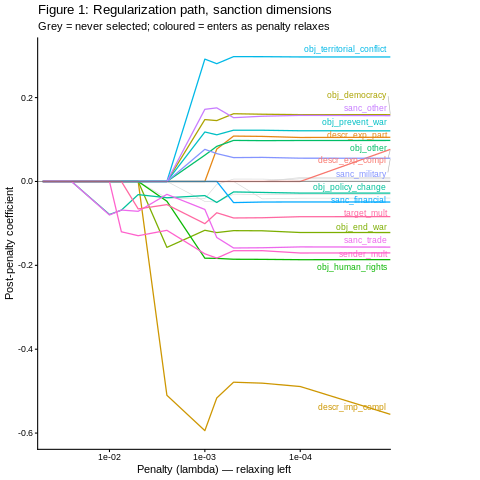

In [ ]:
%%R
library(ggplot2); library(ggrepel); library(dplyr)

fig_path <- sub("Cleaned/?$", "Figures/", path)
dir.create(fig_path, showWarnings = FALSE, recursive = TRUE)

# which dimensions ever leave zero? (label only these)
active <- results |>
  group_by(dimension) |>
  summarise(maxabs = max(abs(coefficient))) |>
  filter(maxabs > 0.05) |>          # was 1e-4 — now only non-trivial coefficients
  pull(dimension)

results$active <- results$dimension %in% active
labs <- results[results$lambda == min(results$lambda) & results$active, ]

p <- ggplot(results, aes(lambda, coefficient, group = dimension)) +
  # inactive dims: faint grey, no label
  geom_line(data = subset(results, !active), colour = "grey85", linewidth = 0.3) +
  # active dims: coloured
  geom_line(data = subset(results, active), aes(colour = dimension),
            linewidth = 0.6, show.legend = FALSE) +
  geom_hline(yintercept = 0, linewidth = 0.3, colour = "grey40") +
  geom_text_repel(data = labs, aes(label = dimension, colour = dimension),
                  direction = "y", hjust = 0, xlim = c(-0.004, NA),
                  segment.size = 0.3, segment.color = "grey70",
                  size = 3, max.overlaps = Inf, show.legend = FALSE) +
  scale_x_continuous(trans = c("log10","reverse"),
                   expand = expansion(mult = c(0.02, 0.35))) +
  theme_classic() +
  theme(plot.margin = margin(5, 90, 5, 5)) +
  labs(x = "Penalty (lambda) — relaxing left", y = "Post-penalty coefficient",
       title = "Figure 1: Regularization path, sanction dimensions",
       subtitle = "Grey = never selected; coloured = enters as penalty relaxes")

ggsave(paste0(fig_path, "fig1_lasso_path.pdf"), p, width = 10, height = 6)
p

In addition: Warning messages:
1: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
2: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
3: In scale_x_continuous(trans = c("log10", "reverse"), expand = expansion(mult = c(0.02,  :
  composition(log-10,reverse) transformation introduced infinite values.
4: In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  conversion failure on 'Penalty  λ  (relaxing →)' in 'mbcsToSbcs': for λ (U+03BB)
5: In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Penalty  λ  (relaxing →)' in 'mbcsToSbcs': -> substituted for → (U+2192)


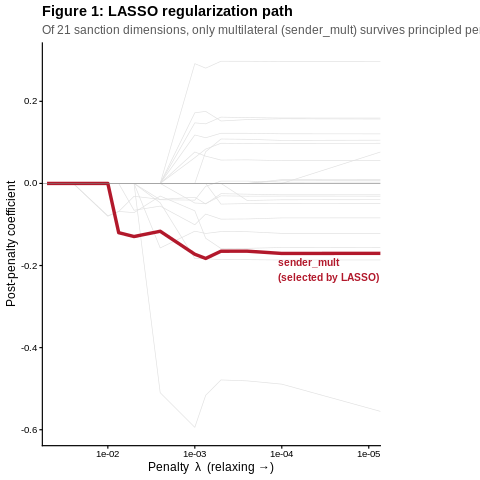

In [ ]:
%%R
library(ggplot2); library(ggrepel); library(dplyr)

fig_path <- sub("Cleaned/?$", "Figures/", path)
dir.create(fig_path, showWarnings = FALSE, recursive = TRUE)

HERO <- "sender_mult"   # the plug-in-selected dimension

# label only non-trivial movers, but always include the hero
active <- results |>
  group_by(dimension) |>
  summarise(maxabs = max(abs(coefficient))) |>
  filter(maxabs > 0.05) |>
  pull(dimension)
active <- union(active, HERO)

results <- results |>
  mutate(role = case_when(dimension == HERO ~ "hero",
                          dimension %in% active ~ "active",
                          TRUE ~ "muted"))
labs <- results |> filter(lambda == min(lambda), role != "muted")

p <- ggplot(results, aes(lambda, coefficient, group = dimension)) +
  # muted: everything that isn't the story — faint, no label
  geom_line(data = filter(results, role == "muted"),
            colour = "grey88", linewidth = 0.3) +
  # active but secondary: thin, soft colour
  geom_line(data = filter(results, role == "active"),
            aes(colour = dimension), linewidth = 0.5, alpha = 0.55,
            show.legend = FALSE) +
  # HERO: thick, dark, opaque — drawn last so it sits on top
  geom_line(data = filter(results, role == "hero"),
            colour = "#b2182b", linewidth = 1.6, show.legend = FALSE) +
  geom_hline(yintercept = 0, linewidth = 0.3, colour = "grey50") +
  # secondary labels: small, grey
  geom_text_repel(data = filter(labs, role == "active"),
                  aes(label = dimension), colour = "grey55",
                  direction = "y", hjust = 0, xlim = c(-0.004, NA),
                  segment.size = 0.2, segment.color = "grey80",
                  size = 2.6, max.overlaps = Inf, show.legend = FALSE) +
  # hero label: bold, red, larger
  geom_text_repel(data = filter(labs, role == "hero"),
                  aes(label = "sender_mult\n(selected by LASSO)"),
                  colour = "#b2182b", fontface = "bold",
                  direction = "y", hjust = 0, xlim = c(-0.004, NA),
                  segment.size = 0.4, segment.color = "#b2182b",
                  size = 3.6, show.legend = FALSE) +
  scale_x_continuous(trans = c("log10", "reverse"),
                     expand = expansion(mult = c(0.02, 0.42))) +
  theme_classic(base_size = 12) +
  theme(plot.margin = margin(6, 100, 6, 6),
        plot.title = element_text(face = "bold"),
        plot.subtitle = element_text(colour = "grey35")) +
  labs(x = "Penalty  λ  (relaxing →)", y = "Post-penalty coefficient",
       title = "Figure 1: LASSO regularization path",
       subtitle = "Of 21 sanction dimensions, only multilateral (sender_mult) survives principled penalization")

ggsave(paste0(fig_path, "fig1_lasso_path_select.pdf"), p, width = 10, height = 6)
p

### Data-driven Lasso

In [ ]:
%%R
# data-driven penalty, no lambda grid; conservative selection
reg2 <- mlfitppml(data    = lasso, dep = "trade",
                  fixed   = list(c("exp_iso3","year"),
                                 c("imp_iso3","year"),
                                 c("exp_iso3","imp_iso3")),
                  penalty = "lasso", method = "plugin",
                  cluster = c("exp_iso3","imp_iso3"))

# assemble: b = NA means not selected
res <- data.frame(dim   = rownames(reg2$beta),
                  b_pre = reg2$beta_pre,
                  b     = reg2$beta,
                  se    = NA)
res$se[!is.na(reg2$beta)] <- reg2$ses
res

User did not specify independent variables. By default, the function takes all variables
        not included in 'dep' or 'fixed' as regressors.                                              dim       b_pre          b
sanc_arms                               sanc_arms  0.00000000  0.0000000
sanc_military                       sanc_military  0.00000000  0.0000000
sanc_trade                             sanc_trade  0.00000000  0.0000000
sanc_financial                     sanc_financial  0.00000000  0.0000000
sanc_travel                           sanc_travel  0.00000000  0.0000000
sanc_other                             sanc_other  0.00000000  0.0000000
target_mult                           target_mult  0.00000000  0.0000000
sender_mult                           sender_mult -0.04991886 -0.1769844
descr_exp_compl                   descr_exp_compl  0.00000000  0.0000000
descr_exp_part                     descr_exp_part  0.00000000  0.0000000
descr_imp_compl                   descr_imp_compl  0.

No of variables: 1
BIC: 13633.8790737363


Nicer table

In [ ]:
%%R
show_ppml <- function(df, caption) {
  d <- ppml_prep(df)
  print(knitr::kable(
    d[, c("term","b","se","pct","t","p","stars")],
    digits = 4, format = "simple",
    col.names = c("Dimension","β","SE","% effect","t","p",""),
    caption = caption
  ))
}

In [ ]:
%%R
sel <- data.frame(term = res$dim, b = res$b, se = res$se)
sel <- sel[!is.na(sel$b) & sel$b != 0, ]
show_ppml(sel, "Plug-In PPML LASSO — selected dimensions")



Table: Plug-In PPML LASSO — selected dimensions

     Dimension           β       SE   % effect         t    p      
---  ------------  -------  -------  ---------  --------  ---  ----
8    sender_mult    -0.177   0.0324   -16.2207   -5.4654    0  *** 


Now Latex

In [ ]:
%%R
tab3 <- data.frame(term = res$dim, b = res$b, se = res$se)
tab3 <- tab3[!is.na(tab3$b) & tab3$b != 0, ]          # selected only → sender_mult
tab3$term <- "Multilateral (multiple senders)"        # readable label for the paper

# view in Colab
tab <- ppml_gt(tab3, "Table 3: Selected sanction dimensions (Plug-In LASSO)",
               "Data-driven penalization retains one dimension")
gtsave(tab, "table3.html")

# LaTeX to output
ppml_latex(tab3, "Sanction dimensions selected by plug-in PPML LASSO", "tab:lasso")

% latex table generated in R 4.6.1 by xtable 1.8-4 package
% Mon Aug 24 11:41:25 2026
\begin{table}[ht]
\centering
\caption{Sanction dimensions selected by plug-in PPML LASSO} 
\label{tab:lasso}
\begin{tabular}{lccc}
  \toprule
Dimension & $\beta$ & SE & \% effect \\ 
  \midrule
Multilateral (multiple senders) & -0.1770*** & (0.0324) & -16.2 \\ 
   \midrule \multicolumn{4}{l}{\footnotesize PPML, three-way FE (exp×year, imp×year, pair); SE clustered by pair. *** p<.01, ** p<.05, * p<.1}\\ \bottomrule
\end{tabular}
\end{table}
